# Vehicle Loitering Analyzer — Colab Debug Harness

This notebook re-implements the **same detection logic** as
`vehicle_loitering_analyst.py` (speed-gated stationarity, per-car dwell
clocks, grace period, zone occupancy, alert video buffering) but runs it
against a **local video file** instead of a live stream, with heavy
per-frame logging so we can see exactly why alerts aren't firing.

It is intentionally standalone — it does **not** import your production
package (`src.core...`) so it can run in a bare Colab runtime. The logic
mirrors your production file line-for-line where it matters; if your real
`SpeedEstimator` implementation differs from the reconstruction below,
that's the first thing to diff.

**Outputs (saved to the current working directory):**
- `debug_log.csv` — per-frame, per-car speed / occupancy / dwell state (the most useful artifact for figuring out *why* it's not triggering)
- `detections/` — annotated JPEG snapshots at key moments (car first becomes occupied, every N seconds while occupied, and at alert time)
- `annotated_output.mp4` — the full annotated run, for scrubbing through visually
- `alert_clips/` — per-car alert video clips, built the same way production builds them (rolling buffer + post-alert unconditional window)


In [ ]:
!pip install -q ultralytics supervision opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import time
import uuid
import numpy as np
import pandas as pd
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

from ultralytics import YOLO
import supervision as sv

os.makedirs("detections", exist_ok=True)
os.makedirs("alert_clips", exist_ok=True)
print("Ready.")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ready.


## 1. Upload your recorded video

Run the cell below, pick the file. If you'd rather mount Drive, comment
this out and just set `VIDEO_PATH` directly.


In [ ]:
from google.colab import files
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print("Using video:", VIDEO_PATH)


Saving vlc-record-2026-08-02-16h40m46s-rtsp___192.168.1.114_554_Streaming_Channels_1-.mp4 to vlc-record-2026-08-02-16h40m46s-rtsp___192.168.1.114_554_Streaming_Channels_1- (1).mp4
Using video: vlc-record-2026-08-02-16h40m46s-rtsp___192.168.1.114_554_Streaming_Channels_1- (1).mp4


## 2. Config — tune these against your footage

These map 1:1 to the constructor args of `VehicleLoiteringAnalyzer`.

**For debugging, `LOITER_THRESHOLD_SECONDS` is set low (10s)** so you
don't have to wait 5 minutes to see an alert fire on a short clip — set
it back to your real production value (e.g. 300) once the logic is
confirmed working.

**If nothing is triggering, the two most common causes are:**
1. `CAR_SPEED_THRESHOLD` (px/s) — this is in **raw pixels of movement per
   second at your video's actual resolution/framerate**, not a
   normalized unit. A car that's visually "parked" can still show several
   px/s of centroid jitter from bbox-detection noise alone. If your
   footage is high-res (e.g. 1920x1080+) or the tracker's box is
   noisy, jitter alone can exceed a low threshold and the car will
   never be judged "stationary". Watch the `car_speed` column in
   `debug_log.csv` for a car you know is parked — if it hovers above
   `CAR_SPEED_THRESHOLD` even when visually still, raise the threshold.
2. `FPS` below must match your **actual video file's fps** (used to
   convert the tracker's per-frame pixel displacement into px/s) — if
   this is wrong, every speed number is wrong and stationarity will
   never gate correctly.


In [ ]:
CONF_THRESHOLD = 0.50
IOU_THRESHOLD = 0.45
ZONE_PADDING_RATIO = 0.4
LOITER_THRESHOLD_SECONDS = 10.0     # << lowered for debugging, restore to 300 for prod
CAR_SPEED_THRESHOLD = 15.0          # px/s -- below this a car counts as parked
CAR_MOTION_WINDOW = 8               # frames used for car speed calc
DWELL_GRACE_FRAMES = 3              # consecutive missed frames tolerated before reset
ALERT_COOLDOWN = 60                 # seconds before re-alerting same car (shortened for debug)

MODEL_PATH = "yolov8l.pt"

MAX_VIDEO_DURATION = 20             # target alert clip length, seconds
VIDEO_FRAME_RATE = 10               # fps to WRITE alert clips at
MIN_FRAMES_FOR_VIDEO = 10

PERSON_CLASS_ID = 0
VEHICLE_CLASS_IDS = {2, 3, 5, 7}    # car, motorcycle, bus, truck

SNAPSHOT_EVERY_SECONDS = 5.0        # save a debug image this often while a car is occupied


# NEW -- ByteTrack tuning against the ID-churn finding. Try raising
# lost_track_buffer substantially (e.g. 60-150 for a ~20-25fps stream)
# so a car isn't given a brand new ID after a 1-3 second detection gap.
BYTETRACK_LOST_TRACK_BUFFER = 90
BYTETRACK_TRACK_ACTIVATION_THRESHOLD = 0.25
BYTETRACK_MINIMUM_MATCHING_THRESHOLD = 0.8



## 3. Reconstructed `SpeedEstimator`

Same px/s-over-a-window logic your production `SpeedEstimator` is
described as using (per-track position history -> displacement / elapsed
time). **If your real implementation differs, swap this class out** —
this is the piece most likely to cause a behavioral mismatch between
this notebook and production, since I don't have the source for the
original.


In [ ]:
class SpeedEstimator:
    def __init__(self, max_history: int = 24):
        self.max_history = max_history
        self.history: Dict[int, deque] = {}

    def update(self, track_id: int, bbox: Tuple[float, float, float, float], frame_idx: int):
        x1, y1, x2, y2 = bbox
        cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        if track_id not in self.history:
            self.history[track_id] = deque(maxlen=self.max_history)
        self.history[track_id].append((frame_idx, cx, cy))

    def get_speed(self, track_id: int, fps: float, window: int = 8) -> float:
        hist = self.history.get(track_id)
        if not hist or len(hist) < 2:
            return 0.0
        recent = list(hist)[-window:]
        if len(recent) < 2:
            return 0.0
        (f0, x0, y0), (f1, x1, y1) = recent[0], recent[-1]
        frame_delta = f1 - f0
        if frame_delta <= 0:
            return 0.0
        dist = ((x1 - x0) ** 2 + (y1 - y0) ** 2) ** 0.5
        elapsed_seconds = frame_delta / fps
        return dist / elapsed_seconds if elapsed_seconds > 0 else 0.0


## 4. Zone / annotation helpers (mirrors production exactly)

In [ ]:
def car_zone(bbox, frame_shape, padding_ratio=ZONE_PADDING_RATIO):
    x1, y1, x2, y2 = bbox
    w, h = x2 - x1, y2 - y1
    pad_x, pad_y = w * padding_ratio, h * padding_ratio
    fh, fw = frame_shape[:2]
    zx1 = max(0, int(x1 - pad_x))
    zy1 = max(0, int(y1 - pad_y))
    zx2 = min(fw, int(x2 + pad_x))
    zy2 = min(fh, int(y2 + pad_y))
    return zx1, zy1, zx2, zy2

def person_in_zone(person_bbox, zone):
    px1, py1, px2, py2 = person_bbox
    foot_x, foot_y = (px1 + px2) / 2, py2
    zx1, zy1, zx2, zy2 = zone
    return zx1 <= foot_x <= zx2 and zy1 <= foot_y <= zy2

def draw_fine_box(frame, x1, y1, x2, y2, color=(60, 200, 255), label=""):
    overlay = frame.copy()
    white = (255, 255, 255)
    bl = 20
    for y in range(y1, y2, 3):
        cv2.line(frame, (x1, y), (x2, y), color, 1)
    for x in range(x1, x2, 3):
        cv2.line(frame, (x, y1), (x, y2), color, 1)
    cv2.line(overlay, (x1, y1), (x1 + bl, y1), white, 1)
    cv2.line(overlay, (x1, y1), (x1, y1 + bl), white, 1)
    cv2.line(overlay, (x2, y1), (x2 - bl, y1), white, 1)
    cv2.line(overlay, (x2, y1), (x2, y1 + bl), white, 1)
    cv2.line(overlay, (x1, y2), (x1 + bl, y2), white, 1)
    cv2.line(overlay, (x1, y2), (x1, y2 - bl), white, 1)
    cv2.line(overlay, (x2, y2), (x2 - bl, y2), white, 1)
    cv2.line(overlay, (x2, y2), (x2, y2 - bl), white, 1)
    frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)
    if label:
        cv2.putText(frame, label, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return frame

def draw_car_box(frame, x1, y1, x2, y2, color, label):
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    cv2.putText(frame, label, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

def annotate_ambient_frame(frame, tracked_cars, person_bboxes, car_zones, car_dwell_seconds,
                            car_speeds, loitering_car_ids):
    """Full-scene view: every car, every person. Used only for the
    whole-run reference video, never for alert clips."""
    annotated = frame.copy()
    zones = list(car_zones.values())
    for (px1, py1, px2, py2) in person_bboxes:
        in_zone = any(person_in_zone((px1, py1, px2, py2), z) for z in zones)
        ix1, iy1, ix2, iy2 = int(px1), int(py1), int(px2), int(py2)
        if in_zone:
            annotated = draw_fine_box(annotated, ix1, iy1, ix2, iy2)
        else:
            cv2.rectangle(annotated, (ix1, iy1), (ix2, iy2), (200, 200, 200), 1)

    for i in range(len(tracked_cars)):
        car_id = int(tracked_cars.tracker_id[i])
        x1, y1, x2, y2 = map(int, tracked_cars.xyxy[i])
        is_loitering = car_id in loitering_car_ids
        color = (0, 0, 255) if is_loitering else (0, 255, 0)
        speed = car_speeds.get(car_id)
        label = f"car {car_id}"
        if speed is not None:
            label += f" | {speed:.0f}px/s"
        if is_loitering:
            dwell = car_dwell_seconds.get(car_id)
            label += f" LOITERING {dwell:.0f}s" if dwell is not None else " LOITERING"
        draw_car_box(annotated, x1, y1, x2, y2, color, label)
        zone = car_zones.get(car_id)
        if zone:
            zx1, zy1, zx2, zy2 = zone
            cv2.rectangle(annotated, (zx1, zy1), (zx2, zy2), (255, 180, 60), 1)
    return annotated

def annotate_car_clip_frame(raw_frame, car_id, car_bbox, zone, person_bboxes,
                             dwell_seconds, speed, is_loitering):
    """Isolated view for ONE car's alert buffer: only this car's box +
    zone, and only the person(s) inside THIS car's zone get the fine box.
    Built fresh from raw_frame every time -- never reuses the ambient
    multi-car annotation, so unrelated cars/people never leak into a
    specific car's alert clip."""
    annotated = raw_frame.copy()

    for pb in person_bboxes:
        if person_in_zone(pb, zone):
            ix1, iy1, ix2, iy2 = map(int, pb)
            annotated = draw_fine_box(annotated, ix1, iy1, ix2, iy2)

    x1, y1, x2, y2 = map(int, car_bbox)
    color = (0, 0, 255) if is_loitering else (0, 255, 0)
    label = f"car {car_id} | {speed:.0f}px/s"
    if is_loitering:
        label += f" LOITERING {dwell_seconds:.0f}s" if dwell_seconds is not None else " LOITERING"
    draw_car_box(annotated, x1, y1, x2, y2, color, label)

    zx1, zy1, zx2, zy2 = zone
    cv2.rectangle(annotated, (zx1, zy1), (zx2, zy2), (255, 180, 60), 1)
    return annotated


## 5. Main processing loop

Runs YOLO + ByteTrack per frame exactly like production's
`_process_pipeline_sync`, but pulling frames from `cv2.VideoCapture`
instead of `StreamCache`, and:
- writes every debug row to `debug_log.csv`
- writes annotated frames to `annotated_output.mp4`
- saves JPEG snapshots to `detections/`
- writes per-car alert clips to `alert_clips/` using the same rolling
  buffer + post-alert unconditional window as production


In [ ]:
model = YOLO(MODEL_PATH)
tracker = sv.ByteTrack(
    lost_track_buffer=BYTETRACK_LOST_TRACK_BUFFER,
    track_activation_threshold=BYTETRACK_TRACK_ACTIVATION_THRESHOLD,
    minimum_matching_threshold=BYTETRACK_MINIMUM_MATCHING_THRESHOLD,
)
speed_estimator = SpeedEstimator(max_history=CAR_MOTION_WINDOW * 3)

cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS) or 25.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {VIDEO_PATH} | {width}x{height} @ {FPS:.2f}fps | {total_frames} frames")

out_writer = cv2.VideoWriter(
    "annotated_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), FPS, (width, height)
)

car_dwell_start: Dict[int, float] = {}
car_miss_streak: Dict[int, int] = {}
car_last_seen: Dict[int, float] = {}
car_alert_times: Dict[int, float] = {}
car_video_pending_until: Dict[int, float] = {}
car_last_snapshot_time: Dict[int, float] = {}
car_first_seen: Dict[int, float] = {}   # NEW -- for track-lifespan diagnostic

car_buffers: Dict[int, deque] = defaultdict(lambda: deque(maxlen=VIDEO_FRAME_RATE * MAX_VIDEO_DURATION))

debug_rows = []
track_lifespan_rows = []   # NEW
alerts = []
frame_idx = 0
STALE_TRACK_SECONDS = 3.0

while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_idx += 1
    sim_time = frame_idx / FPS

    results = model.predict(
        frame, imgsz=640, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
        classes=[PERSON_CLASS_ID, *VEHICLE_CLASS_IDS], verbose=False,
    )
    detections = sv.Detections.from_ultralytics(results[0])
    vehicle_mask = np.isin(detections.class_id, list(VEHICLE_CLASS_IDS))
    person_mask = detections.class_id == PERSON_CLASS_ID

    tracked_cars = tracker.update_with_detections(detections[vehicle_mask])
    person_bboxes = [tuple(b) for b in detections[person_mask].xyxy]

    car_zones = {}
    car_bboxes_this_frame = {}
    car_dwell_seconds = {}
    car_speeds = {}
    loitering_car_ids = set()
    active_car_ids = set()
    needs_buffer_ids = set()

    for i in range(len(tracked_cars)):
        car_id = int(tracked_cars.tracker_id[i])
        car_bbox = tuple(tracked_cars.xyxy[i])
        car_bboxes_this_frame[car_id] = car_bbox
        active_car_ids.add(car_id)
        car_last_seen[car_id] = sim_time
        if car_id not in car_first_seen:
            car_first_seen[car_id] = sim_time

        speed_estimator.update(car_id, car_bbox, frame_idx)
        car_speed = speed_estimator.get_speed(car_id, FPS, window=CAR_MOTION_WINDOW)
        car_speeds[car_id] = car_speed
        is_stationary = car_speed < CAR_SPEED_THRESHOLD

        zone = car_zone(car_bbox, frame.shape)
        car_zones[car_id] = zone
        person_present = any(person_in_zone(pb, zone) for pb in person_bboxes)
        occupied = is_stationary and person_present

        dwell = None
        if occupied:
            car_miss_streak.pop(car_id, None)
            if car_id not in car_dwell_start:
                car_dwell_start[car_id] = sim_time
            dwell = sim_time - car_dwell_start[car_id]
            car_dwell_seconds[car_id] = dwell
            needs_buffer_ids.add(car_id)

            if dwell >= LOITER_THRESHOLD_SECONDS:
                loitering_car_ids.add(car_id)
                last_alert = car_alert_times.get(car_id, -1e9)
                if sim_time - last_alert >= ALERT_COOLDOWN:
                    car_alert_times[car_id] = sim_time
                    car_video_pending_until[car_id] = sim_time + MAX_VIDEO_DURATION
                    alerts.append({
                        "alert_id": str(uuid.uuid4()),
                        "car_track_id": car_id,
                        "video_time_seconds": round(sim_time, 2),
                        "dwell_seconds": round(dwell, 2),
                        "car_bbox": [int(v) for v in car_bbox],
                    })
                    print(f"[ALERT] t={sim_time:.1f}s car={car_id} dwell={dwell:.1f}s")
        else:
            if car_id in car_dwell_start:
                streak = car_miss_streak.get(car_id, 0) + 1
                car_miss_streak[car_id] = streak
                if streak > DWELL_GRACE_FRAMES:
                    car_dwell_start.pop(car_id, None)
                    car_miss_streak.pop(car_id, None)
                else:
                    dwell = sim_time - car_dwell_start[car_id]
                    car_dwell_seconds[car_id] = dwell

        pending_until = car_video_pending_until.get(car_id, 0.0)
        in_pending_window = bool(pending_until) and sim_time < pending_until
        if in_pending_window:
            loitering_car_ids.add(car_id)
            needs_buffer_ids.add(car_id)
        if pending_until and sim_time >= pending_until:
            car_video_pending_until.pop(car_id, None)

        debug_rows.append({
            "frame": frame_idx,
            "video_time_s": round(sim_time, 2),
            "car_id": car_id,
            "car_speed_px_s": round(car_speed, 2),
            "is_stationary": is_stationary,
            "person_present": person_present,
            "occupied": occupied,
            "dwell_s": round(dwell, 2) if dwell is not None else None,
            "miss_streak": car_miss_streak.get(car_id, 0),
        })

    for cid in list(car_last_seen.keys()):
        if cid not in active_car_ids and sim_time - car_last_seen[cid] > STALE_TRACK_SECONDS:
            track_lifespan_rows.append({
                "car_id": cid,
                "first_seen_s": car_first_seen.get(cid),
                "last_seen_s": car_last_seen.get(cid),
                "lifespan_s": car_last_seen.get(cid, 0) - car_first_seen.get(cid, 0),
            })
            for d in (car_dwell_start, car_miss_streak, car_last_seen, car_alert_times,
                      car_video_pending_until, car_last_snapshot_time, car_first_seen):
                d.pop(cid, None)
            car_buffers.pop(cid, None)

    # Ambient full-scene frame -- for the whole-run reference video only.
    ambient = annotate_ambient_frame(frame, tracked_cars, person_bboxes, car_zones,
                                      car_dwell_seconds, car_speeds, loitering_car_ids)
    out_writer.write(ambient)

    # Isolated per-car frames -- ONLY this car + ONLY people in its zone.
    for car_id in needs_buffer_ids:
        car_clip_frame = annotate_car_clip_frame(
            frame, car_id, car_bboxes_this_frame[car_id], car_zones[car_id],
            person_bboxes, car_dwell_seconds.get(car_id), car_speeds.get(car_id),
            is_loitering=(car_id in loitering_car_ids),
        )
        car_buffers[car_id].append(car_clip_frame)

        last_snap = car_last_snapshot_time.get(car_id, -1e9)
        if sim_time - last_snap >= SNAPSHOT_EVERY_SECONDS:
            car_last_snapshot_time[car_id] = sim_time
            cv2.imwrite(f"detections/car{car_id}_t{sim_time:.1f}s.jpg", car_clip_frame)

    if frame_idx % 100 == 0:
        print(f"...processed {frame_idx}/{total_frames} frames "
              f"(cars tracked: {len(active_car_ids)})")

cap.release()
out_writer.release()

# flush lifespans for any car still active at end of video
for cid in car_first_seen:
    track_lifespan_rows.append({
        "car_id": cid,
        "first_seen_s": car_first_seen.get(cid),
        "last_seen_s": car_last_seen.get(cid),
        "lifespan_s": car_last_seen.get(cid, 0) - car_first_seen.get(cid, 0),
    })

debug_df = pd.DataFrame(debug_rows)
debug_df.to_csv("debug_log.csv", index=False)
lifespan_df = pd.DataFrame(track_lifespan_rows).drop_duplicates(subset="car_id", keep="last")
lifespan_df.to_csv("track_lifespans.csv", index=False)
print(f"\nDone. {len(alerts)} alert(s). debug_log.csv has {len(debug_df)} rows. "
      f"{lifespan_df['car_id'].nunique()} unique car track IDs seen.")


FileNotFoundError: [Errno 2] No such file or directory: 'yolov11m.pt'

## 6. Write per-car alert clips

For every alert, dump that car's rolling buffer to an mp4 in
`alert_clips/` — same idea as production's `create_and_upload_video`
(minus the upload step, minus ffmpeg re-encode — this writes directly
with OpenCV, good enough for local review).


In [ ]:
for alert in alerts:
    car_id = alert["car_track_id"]
    frames = list(car_buffers.get(car_id, []))
    if not frames:
        print(f"No buffered frames for car {car_id}, skipping clip")
        continue
    if len(frames) < MIN_FRAMES_FOR_VIDEO:
        frames = frames + [frames[-1]] * (MIN_FRAMES_FOR_VIDEO - len(frames))

    h, w = frames[0].shape[:2]
    out_path = f"alert_clips/car{car_id}_{alert['alert_id'][:8]}.mp4"
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), VIDEO_FRAME_RATE, (w, h))
    for f in frames:
        writer.write(f)
    writer.release()
    print(f"Wrote {out_path} ({len(frames)} frames, ~{len(frames)/VIDEO_FRAME_RATE:.1f}s)")


## 7. Inspect the debug log

This is the important part for figuring out *why* production isn't
triggering. Look specifically at a car you know is parked with a person
standing next to it: is `is_stationary` ever `False` when it shouldn't
be? Is `person_present` flickering `False`/`True`? Is `occupied` never
`True` for long enough to cross `LOITER_THRESHOLD_SECONDS`?


car_id
1     0.375000
2     0.073718
3     0.009615
4     0.000000
5     0.009615
6     0.038462
7     0.000000
8     0.041667
9     0.000000
10    0.047101
11    0.059524
12    0.000000
13    0.000000
14    0.000000
15    0.000000
16    0.000000
17    0.000000
18    0.068966
19    0.000000
20    0.000000
Name: fraction_of_frames_occupied, dtype: float64

        count      mean        std  min     25%    50%     75%        max
car_id                                                                   
1       312.0  0.582276   0.812988  0.0  0.1300  0.290  0.6225   5.040000
2       312.0  2.484936   2.809214  0.0  0.6650  1.345  2.9225  14.550000
3       312.0  7.064904   7.218616  0.0  2.2200  4.570  8.7925  42.490002
4       312.0  0.154936   0.137831  0.0  0.0600  0.120  0.1900   0.640000
5       312.0  0.835064   0.832016  0.0  0.2875  0.540  1.0825   5.130000
6       312.0  0.411859   0.340271  0.0  0.1975  0.320  0.5225   2.270000
7       312.0  1.302724   1.246871  0.0  0.4300  0

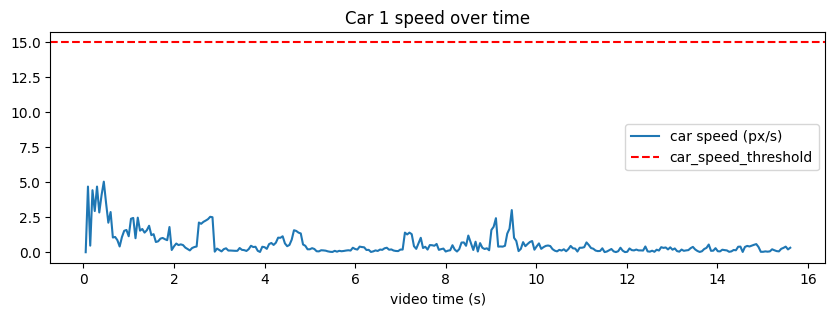

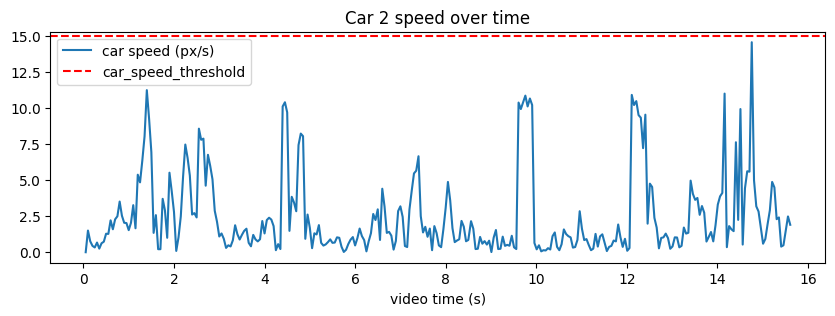

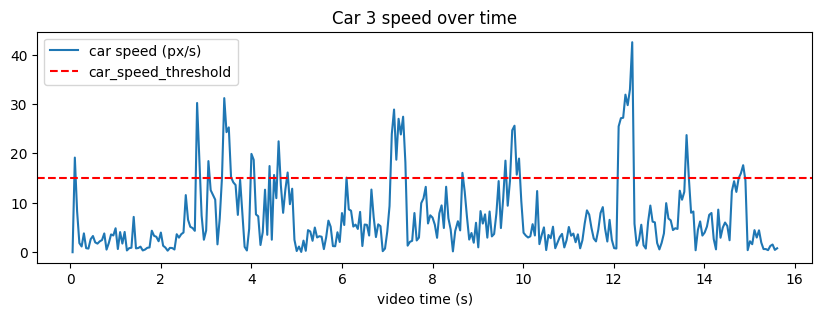

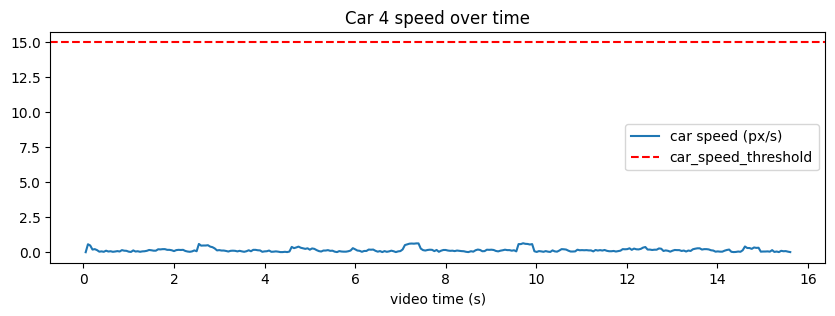

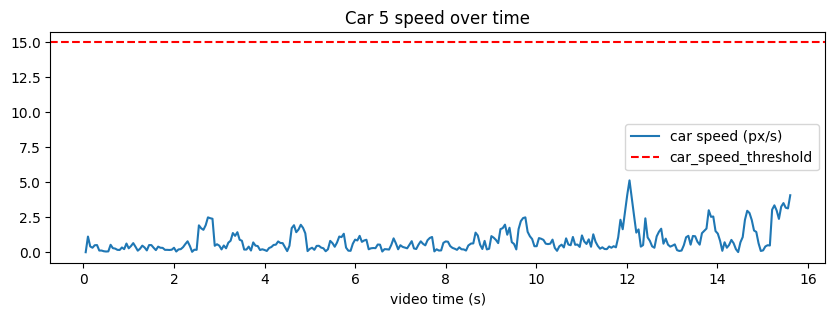

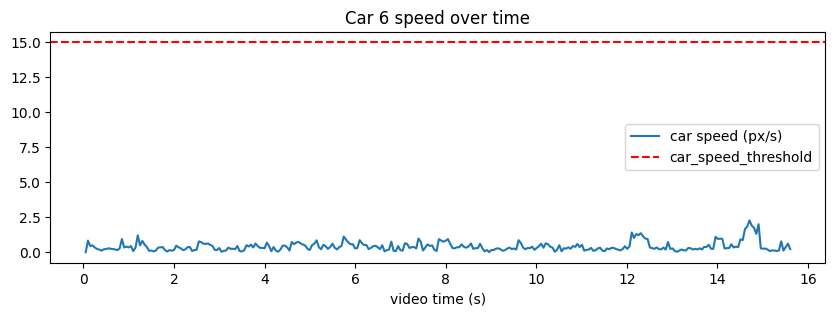

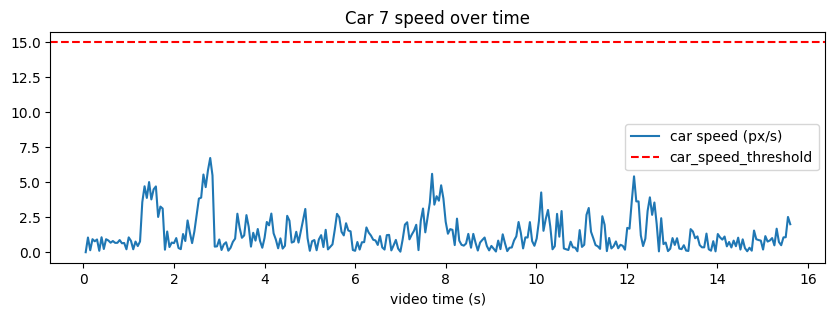

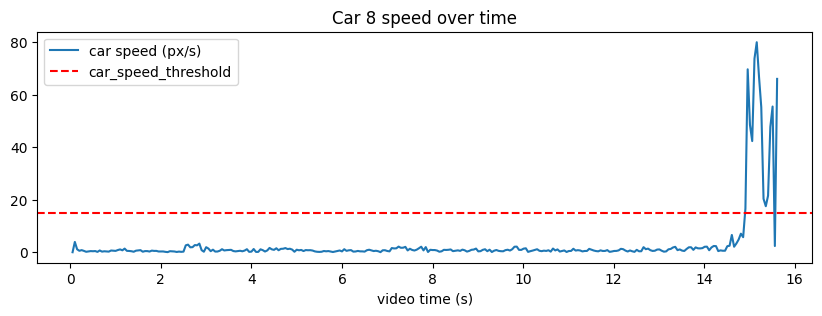

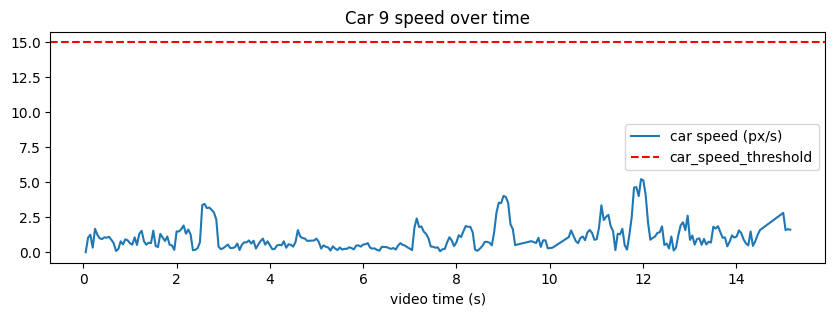

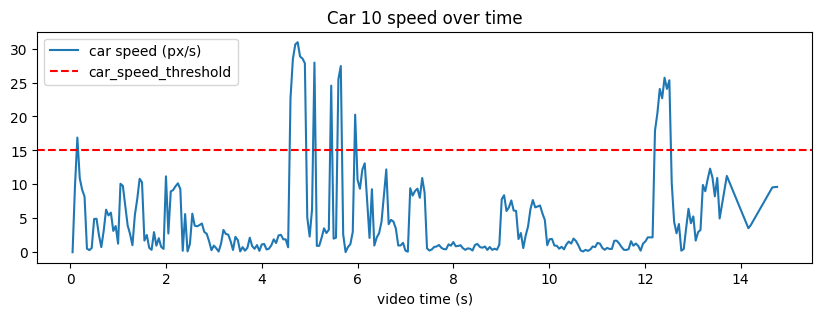

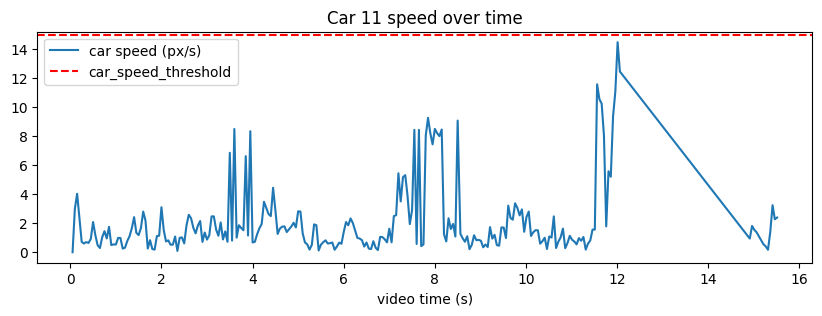

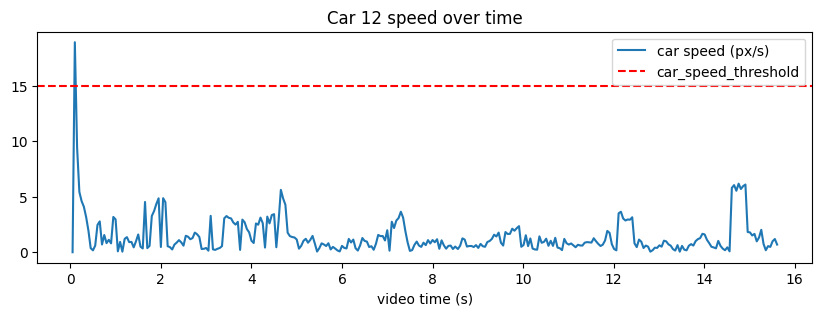

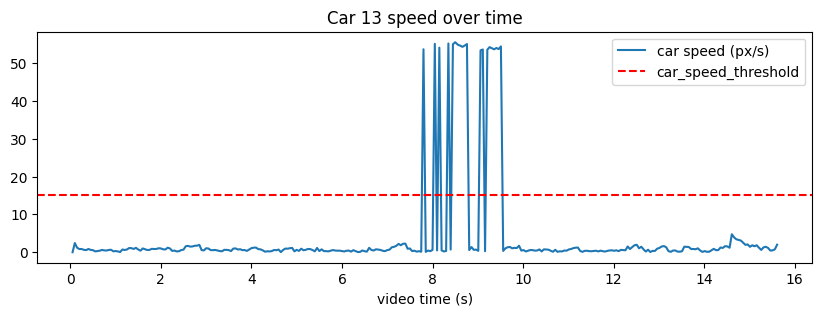

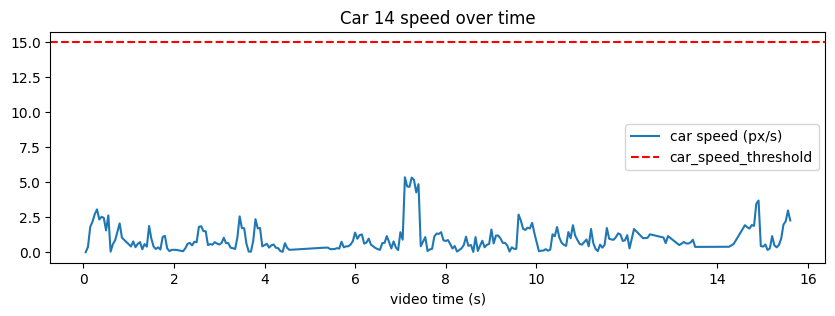

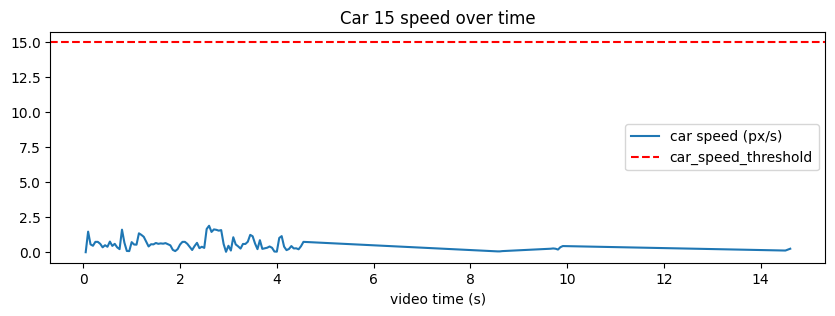

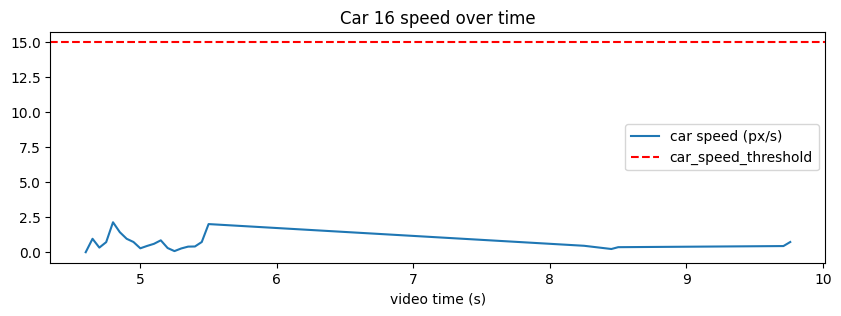

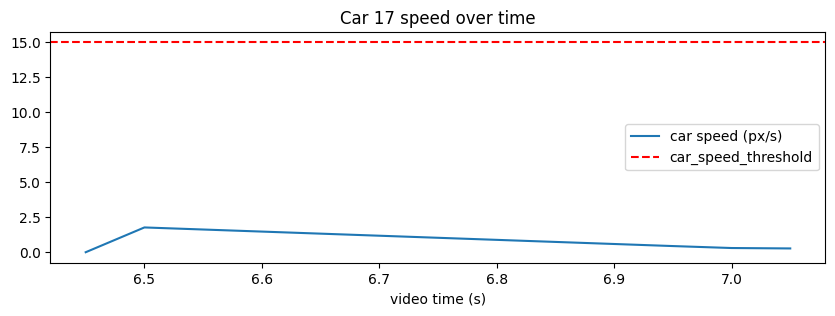

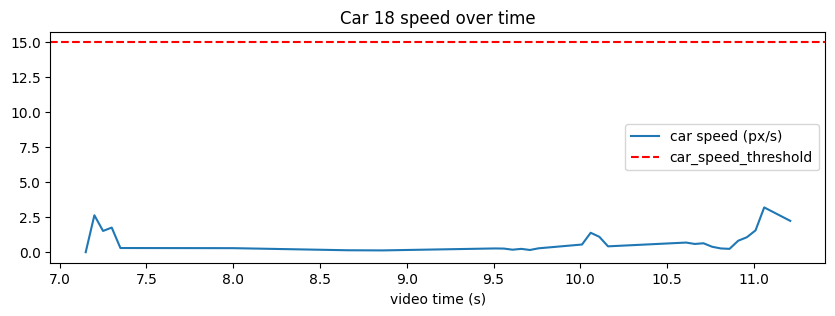

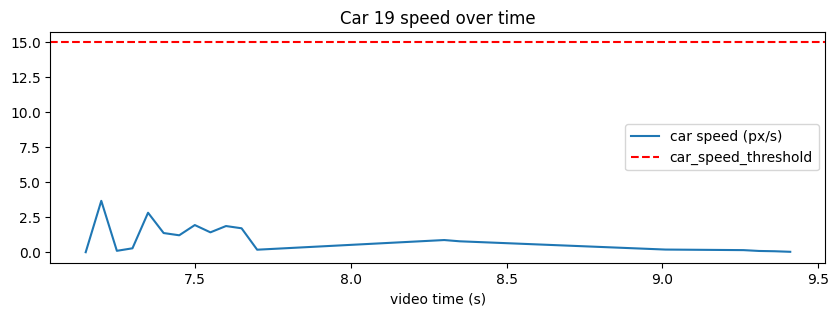

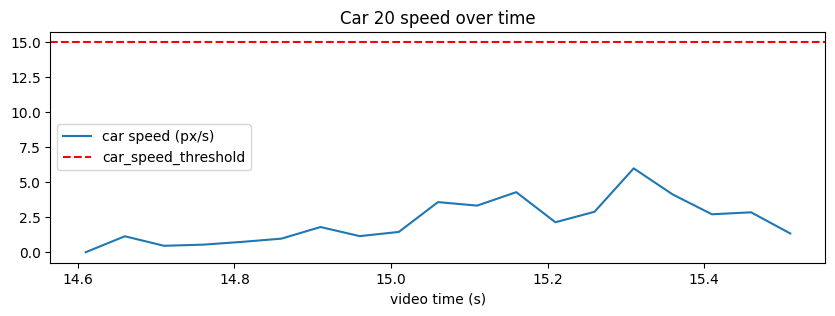

In [ ]:
import matplotlib.pyplot as plt

debug_df = pd.read_csv("debug_log.csv")
print(debug_df.groupby("car_id")["occupied"].mean().rename("fraction_of_frames_occupied"))
print()
print(debug_df.groupby("car_id")["car_speed_px_s"].describe())

for car_id, g in debug_df.groupby("car_id"):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(g["video_time_s"], g["car_speed_px_s"], label="car speed (px/s)")
    ax.axhline(CAR_SPEED_THRESHOLD, color="red", linestyle="--", label="car_speed_threshold")
    ax.set_title(f"Car {car_id} speed over time")
    ax.set_xlabel("video time (s)")
    ax.legend()
    plt.show()


## 8. NEW -- separate "never stationary long enough" from "no person ever there"

This is the cell that actually answers "what happened" for cars that
never alerted. For each car:
- `pct_stationary`: fraction of frames where `is_stationary` was True
- `pct_person_present`: fraction of frames a person was anywhere in its zone
- `pct_occupied`: fraction of frames BOTH were true (this is what the
  dwell clock actually needs, continuously, for `LOITER_THRESHOLD_SECONDS`)
- `max_continuous_occupied_s`: the longest unbroken (grace-period-aware)
  occupied streak the car ever had -- if this never reaches your
  threshold, that tells you definitively why it didn't alert, and
  whether it's a stationarity problem or a person-presence problem.

In [ ]:
def max_continuous_occupied_seconds(g, fps, grace_frames=DWELL_GRACE_FRAMES):
    g = g.sort_values("video_time_s")
    occ = g["occupied"].to_numpy()
    times = g["video_time_s"].to_numpy()
    best = 0.0
    start_t = None
    miss = 0
    for occupied_flag, t in zip(occ, times):
        if occupied_flag:
            if start_t is None:
                start_t = t
            miss = 0
        else:
            if start_t is not None:
                miss += 1
                if miss > grace_frames:
                    best = max(best, t - start_t)
                    start_t = None
                    miss = 0
    if start_t is not None:
        best = max(best, times[-1] - start_t)
    return best

summary_rows = []
for car_id, g in debug_df.groupby("car_id"):
    summary_rows.append({
        "car_id": car_id,
        "pct_stationary": round(g["is_stationary"].mean() * 100, 1),
        "pct_person_present": round(g["person_present"].mean() * 100, 1),
        "pct_occupied": round(g["occupied"].mean() * 100, 1),
        "max_continuous_occupied_s": round(max_continuous_occupied_seconds(g, FPS), 1),
        "did_alert": car_id in {a["car_track_id"] for a in alerts},
    })

summary_df = pd.DataFrame(summary_rows).sort_values("max_continuous_occupied_s", ascending=False)
summary_df


,car_id,pct_stationary,pct_person_present,pct_occupied,max_continuous_occupied_s,did_alert
10,11,100.0,6.0,6.0,3.5,False
0,1,100.0,37.5,37.5,1.4,False
9,10,92.8,6.9,4.7,1.2,False
1,2,100.0,7.4,7.4,1.0,False
7,8,95.5,7.4,4.2,0.7,False
17,18,100.0,6.9,6.9,0.7,False
5,6,100.0,3.8,3.8,0.5,False
2,3,87.2,1.0,1.0,0.2,False
4,5,100.0,1.0,1.0,0.2,False
3,4,100.0,0.0,0.0,0.0,False


Unique car track IDs seen: 20
count    20.000000
mean     11.474225
std       6.335447
min       0.100059
25%       4.877859
50%      15.559119
75%      15.559119
max      15.559119
Name: lifespan_s, dtype: float64


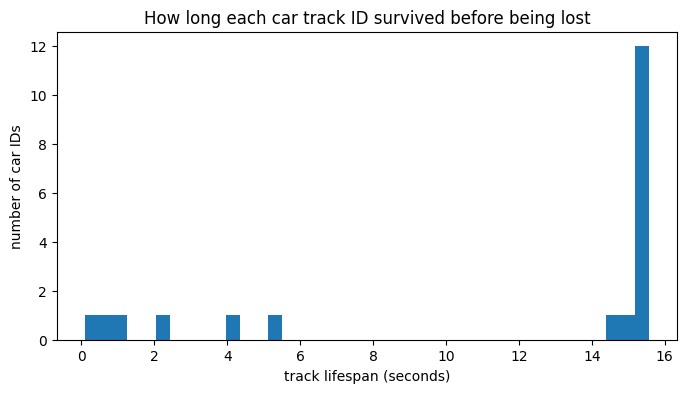


Longest-lived tracks (these are probably your real, cleanly-tracked cars):
    car_id  first_seen_s  last_seen_s  lifespan_s
7        4      0.050029    15.609148   15.559119
6        3      0.050029    15.609148   15.559119
5        2      0.050029    15.609148   15.559119
4        1      0.050029    15.609148   15.559119
15      12      0.050029    15.609148   15.559119
16      13      0.050029    15.609148   15.559119
17      14      0.050029    15.609148   15.559119
11       8      0.050029    15.609148   15.559119
8        5      0.050029    15.609148   15.559119
9        6      0.050029    15.609148   15.559119
10       7      0.050029    15.609148   15.559119
14      11      0.050029    15.509089   15.459060
12       9      0.050029    15.158884   15.108855
13      10      0.050029    14.758650   14.708620
2       16      4.602697     9.755717    5.153020


In [ ]:
lifespan_df = pd.read_csv("track_lifespans.csv")
print(f"Unique car track IDs seen: {lifespan_df['car_id'].nunique()}")
print(lifespan_df["lifespan_s"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lifespan_df["lifespan_s"], bins=40)
ax.set_xlabel("track lifespan (seconds)")
ax.set_ylabel("number of car IDs")
ax.set_title("How long each car track ID survived before being lost")
plt.show()

print("\nLongest-lived tracks (these are probably your real, cleanly-tracked cars):")
print(lifespan_df.sort_values("lifespan_s", ascending=False).head(15))


In [ ]:
from google.colab import files as colab_files
# Uncomment to download outputs directly from Colab:
colab_files.download("debug_log.csv")
colab_files.download("annotated_output.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>